This notebook is here as a last minute thing after the error with the jupiter notebook in visual studio that stoped working

For this I need the:
validation set /beta
the ridge regression model
the featue weigths (just in case), please make sure they are in colab folder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import pickle

In [4]:
shap.__version__

'0.46.0'

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix

In [6]:
ridge_model = pickle.load(open('ridge_model_smote.pkl', 'rb'))


In [7]:
test_file="RNAseq_Combat_z_score_Test_set.csv"

In [8]:
test_data = pd.read_csv(test_file)
test_data.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1', 'Age', 'Status', 'Experiment', 'Age.1', 'Sample',
       'Sex'],
      dtype='object', length=34511)

In [9]:
# prompt: remove NAN in X_test_data

import pandas as pd
import numpy as np

# ... (your existing code)

test_data = test_data.fillna(0) # Replace NaN values with 0
# or
# X_test_data = X_test_data.dropna() # Remove rows with NaN values
# or other methods to handle NaN values depending on the context

# ... (rest of your code)

In [10]:
test_data.drop(columns=["Age.1"], inplace=True)
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]
z_test_data = z_test_data["Experiment"]

In [11]:
# prompt: Create a dataframe that has the columns Age, Experiment and the Sample as index using test_data

# Create the DataFrame
df= pd.DataFrame({'Age': y_test_data, 'Experiment': z_test_data})
df = df.set_index(pd.Index(range(len(df)))) #Setting the sample as index

df

,Age,Experiment
0,24.0,GSE157585
1,18.0,GSE167186
2,23.0,GSE167186
3,26.4,GSE60590
4,71.0,GSE157585
...,...,...
103,71.0,GSE157585
104,23.0,GSE167186
105,72.0,GSE164471
106,71.0,GSE157585


In [12]:
X_test_data

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,-0.025402,-0.027702,-0.001319,-0.025818,-0.025609,-0.027285,-0.023140,-0.022924,-0.020265,-0.024281,...,-0.023543,-0.027779,-0.027220,-0.027766,-0.026714,-0.024396,-0.027726,-0.027783,-0.026468,-0.027604
104,-0.020350,-0.026256,-0.006269,-0.023194,-0.023090,-0.025255,-0.018721,-0.020525,-0.019203,-0.021669,...,-0.020478,-0.026193,-0.025998,-0.026158,-0.025965,-0.025516,-0.026124,-0.026181,-0.018528,-0.025961
105,-0.023877,-0.028292,-0.003818,-0.026749,-0.026163,-0.027351,-0.020208,-0.023042,-0.024271,-0.025981,...,-0.020212,-0.028309,-0.028245,-0.028309,-0.028252,-0.027582,-0.028327,-0.028302,-0.027453,-0.027923
106,-0.025112,-0.029562,0.000282,-0.026724,-0.027813,-0.029708,-0.013082,-0.021109,-0.021883,-0.024146,...,-0.025092,-0.030153,-0.030124,-0.030141,-0.029958,-0.029177,-0.030107,-0.030156,-0.028848,-0.029939


In [13]:

y_pred = ridge_model.predict(X_test_data)
y_pred



array([29.05681957, 24.4220291 , 20.97724608, 41.66660629, 77.62126555,
       24.51784312, 61.74541673, 30.69474696, 23.18648144, 79.15509403,
       61.68542774, 70.96370981, 74.07951931, 45.41790299, 70.99516315,
       75.61766582, 72.86561305, 65.97808613, 42.80535334, 21.05408111,
       19.20746352, 68.56182807, 87.84874062, 55.21209813, 34.1545599 ,
       71.28058889, 81.62261319, 26.18495418, 49.19909833, 29.96123437,
       38.15233563, 18.80750833, 55.86885107, 24.86880311, 75.29709353,
       42.90930283, 79.20072086, 19.83589812, 58.08909671, 24.91732159,
       68.25639877, 21.71098557, 72.89215981, 75.43610744, 93.18812583,
       37.21811133, 80.51833436, 23.20866639, 78.11236851, 49.3013132 ,
       65.05850862, 69.03505178, 41.26626805, 81.55855005, 72.58901515,
       46.39505083, 70.67187271, 61.36276324, 49.71547598, 30.45972371,
       79.93836664, 66.816107  , 75.95656493, 80.97624903, 22.58160715,
       56.03061623, 25.60914135, 70.85786509,  8.95409884, 34.65

In [14]:

# Calculate evaluation metrics
mse = mean_squared_error(y_test_data, y_pred)
rmse = mean_squared_error(y_test_data, y_pred)#, squared=False)  # Calculate RMSE from MSE
mae = mean_absolute_error(y_test_data, y_pred)
r2 = r2_score(y_test_data, y_pred)


result_metrics = {"Method": "Ridge Regression",  "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}


results = pd.DataFrame({'Actual': y_test_data, 'Predicted': y_pred, 'Group': z_test_data})

In [15]:
results

,Actual,Predicted,Group
0,24.0,29.056820,GSE157585
1,18.0,24.422029,GSE167186
2,23.0,20.977246,GSE167186
3,26.4,41.666606,GSE60590
4,71.0,77.621266,GSE157585
...,...,...,...
103,71.0,71.858171,GSE157585
104,23.0,26.527594,GSE167186
105,72.0,49.635809,GSE164471
106,71.0,64.093399,GSE157585


In [16]:
#results.to_csv("results_validation_untoached_Ridge.csv", index=False)

In [17]:
!pip install pybiomart
!pip install scanpy


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
!pip install decoupler


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
from convert_ensembl_2_symbol import convert_to_symbol, filter_nameless_genes

In [21]:
from anndata import AnnData
import scanpy as sc



In [22]:
# prompt: save annot in pkl

import pickle

# ... (your existing code)

# Save the 'annot' DataFrame to a pickle file
#annot.to_pickle("annot.pkl")

# Load the annot Dataframe from picke
annot = pd.read_pickle("annot.pkl")

In [23]:
ensebl_names = X_test_data.columns
ensebl_names = filter_nameless_genes(ensebl_names, annot)
symbol_names = convert_to_symbol(ensebl_names, annot)

In [24]:
# prompt: take the X_test_data columns, if the value of .split(".")[0] is in ensebl_names, get the same index on ensebl_names but in symbol_names

# Assuming 'ensebl_names' and 'symbol_names' are lists of the same length
# and that the indices in the lists correspond correctly.

# Create a mapping from Ensembl IDs to gene symbols
ensembl_to_symbol = dict(zip(ensebl_names, symbol_names))

# if symbol_name is nan or variant, replace with the same ensebl_name
for key, value in ensembl_to_symbol.items():
    if pd.isna(value) or value =="nan" or value is None:
        ensembl_to_symbol[key] = key

#if X_test_data.colum is not in ensembl_to_symbol, add it with value the same as the key
for col in X_test_data.columns:
    if col not in ensembl_to_symbol:
        ensembl_to_symbol[col] = col
# Initialize an empty list to store the gene symbols for X_test_data columns
selected_symbols = []


# Iterate over columns in X_test_data
for ensembl_id in X_test_data.columns:
    if ensembl_id in ensembl_to_symbol:
        selected_symbols.append(ensembl_to_symbol[ensembl_id])
    else:
        # Handle cases where the Ensembl ID is not found in the mapping.
        # For example, append the original column name or a placeholder
        selected_symbols.append(ensembl_id) # Or selected_symbols.append("Not Found")

# Now 'selected_symbols' contains the corresponding gene symbols for the columns
# in X_test_data, or the original column name if the ensembl ID was not found.

In [25]:
selected_symbols[:10]

['TSPAN6',
 'TNMD',
 'DPM1',
 'SCYL3',
 'FIRRM',
 'FGR',
 'CFH',
 'FUCA2',
 'GCLC',
 'NFYA']

In [26]:
X_test_data.columns = selected_symbols
X_test_data.head()

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,C4orf36,TUSC2P1,ENSG00000285471.1,OR4M2-OT1,ENSG00000285476.1,H2BK1,OR1Q1BP,ENSG00000285505.1,ENSG00000285508.1,TBCEL-TECTA
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.021222,-0.024522,-0.024480,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.020113,-0.025321,-0.025120,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.022675,-0.030003,-0.029834,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.025233,-0.028767,-0.029022,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.020558,-0.026779,-0.026721,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577


In [27]:

# Assuming X_test_data is your feature matrix for the test set
explainer = shap.Explainer(ridge_model, X_test_data)
shap_values = explainer(X_test_data)

# You can now access and visualize the SHAP values
# shap.plots.beeswarm(shap_values)  # Bee swarm plot
# shap.plots.bar(shap_values) # Bar plot
# shap.summary_plot(shap_values, X_test_data) # Summary plot

# To get SHAP values for a specific instance:
# shap_values[0]  # SHAP values for the first instance in X_test_data

# To get the base value (expected value):
# explainer.expected_value

In [28]:
# prompt: Save the SHAP value for each gene

# Assuming X_test_data is your feature matrix for the test set
# and shap_values are already calculated as in your provided code.

# Create a DataFrame to store SHAP values for each gene
shap_df = pd.DataFrame(shap_values.values, columns=X_test_data.columns)
shap_df
# Save the DataFrame to a CSV file
shap_df.to_csv("shap_values_by_gene_Ridge_40_extended.csv", index=False)

In [29]:
shap_df['MYL2']

0      -5.841457
1     -17.497114
2     -18.356045
3       4.741161
4      15.087287
         ...    
103    18.429607
104   -15.999352
105    -0.179563
106    16.758219
107     5.235073
Name: MYL2, Length: 108, dtype: float64

In [32]:
results.head()
results['Difference'] = results['Actual'] - results['Predicted']

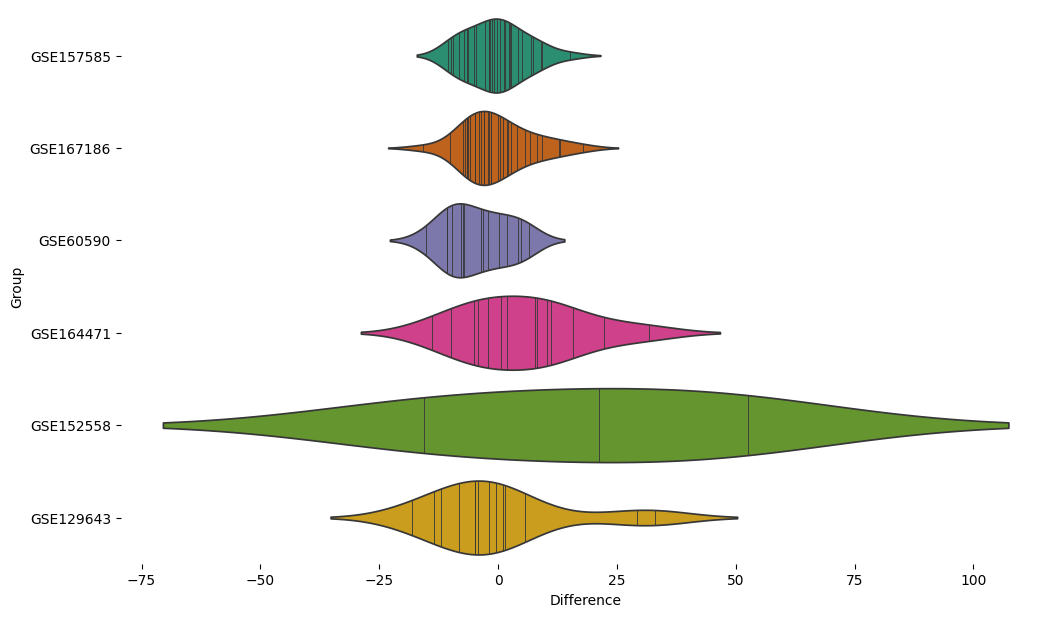

In [33]:
# @title Group vs Difference

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results['Group'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results, x='Difference', y='Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.savefig("Group_vs_Difference_Ridge_40_extended.svg", bbox_inches='tight')

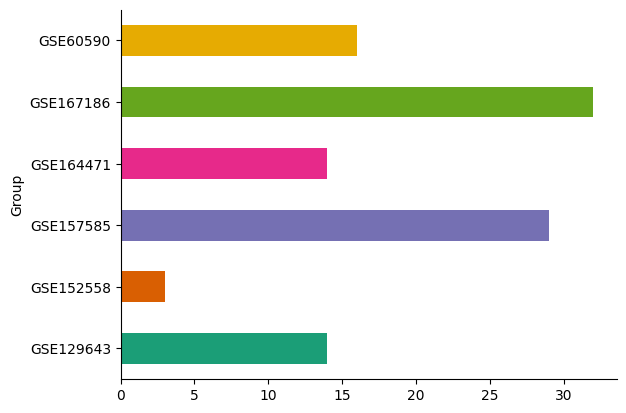

In [34]:
# @title Group

from matplotlib import pyplot as plt
import seaborn as sns
results.groupby('Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.savefig("Group_Ridge_40_extended.svg", bbox_inches='tight')

In [35]:
# prompt: Using dataframe results: calculate per group, what is the average absolute difference between predicted and Actual

# Calculate the absolute difference between predicted and actual values
results['Difference'] = abs(results['Predicted'] - results['Actual'])

# Group by 'Group' and calculate the average absolute difference
average_difference_by_group = results.groupby('Group')['Difference'].mean()

# Display the result
average_difference_by_group


Group
GSE129643     9.879993
GSE152558    29.796602
GSE157585     5.030312
GSE164471    10.381234
GSE167186     5.678292
GSE60590      6.626139
Name: Difference, dtype: float64

In [36]:
results[results["Group"]=="GSE152558"]

,Actual,Predicted,Group,Difference
10,46.0,61.685428,GSE152558,15.685428
37,41.0,19.835898,GSE152558,21.164102
59,83.0,30.459724,GSE152558,52.540276


In [37]:
with open('shap_values_ridge.pkl', 'wb') as f:
    pickle.dump(shap_values, f)

Sample 2/ 108 
 Age: 23.0 
 Experiment: GSE167186


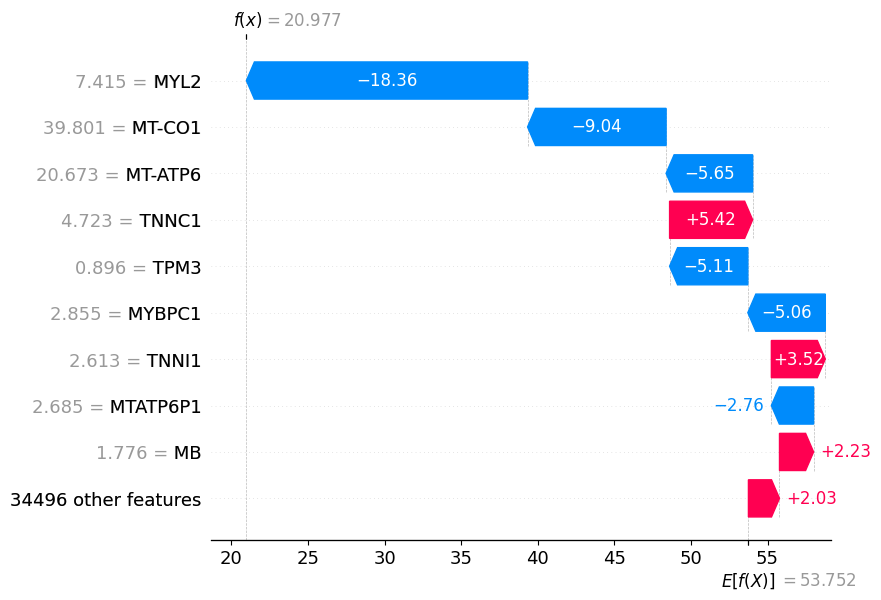

<Figure size 640x480 with 0 Axes>

In [38]:
import matplotlib.pyplot as plt
index=2
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]}"
print(title)
shap.plots.waterfall(shap_values[index])

plt.savefig('summary_plot_waterfal_RIDGE_40.svg', bbox_inches='tight')

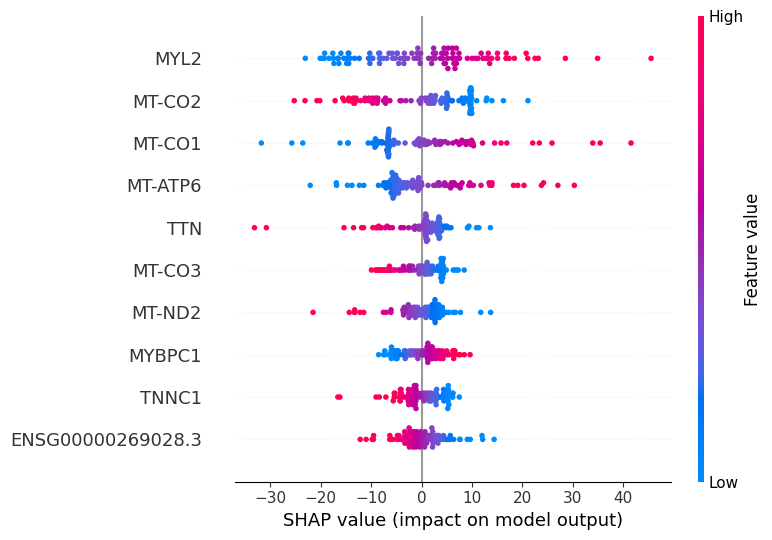

In [39]:
# prompt: Run the shap.summary_plot

plot_shap =shap.summary_plot(shap_values, X_test_data, max_display=10)

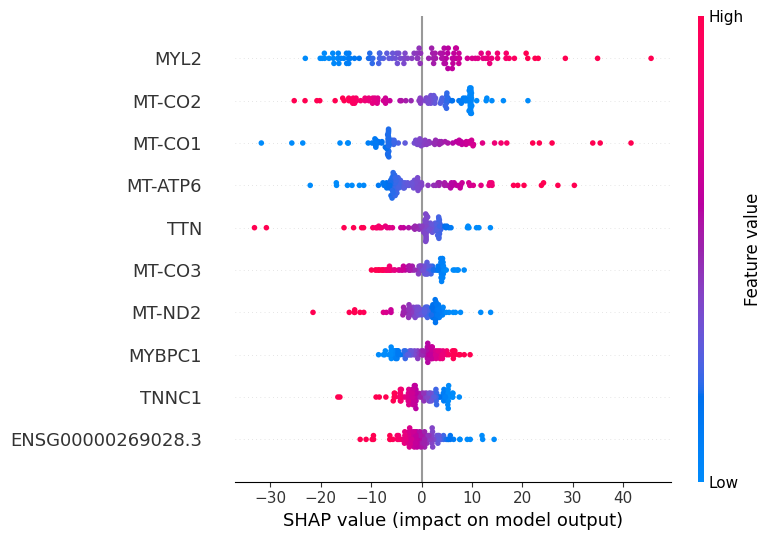

In [40]:
# prompt: save the shap figure

import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test_data, max_display=10, show=False)
plt.savefig('summary_plot_RIDGE_40.svg', bbox_inches='tight')

Let's try to get by gene the shap value

In [41]:
feature_name = "MYL2"  # Replace with the feature of interest
feature_index = X_test_data.columns.get_loc(feature_name)  # Get the column index for the feature

In [42]:
explainer.expected_value

53.75167188820227

In [43]:
list(X_test_data[feature_name].values )

[9.806431421867842,
 7.57949877648002,
 7.415391189879538,
 11.828349049380078,
 13.805082365677166,
 10.396184449153042,
 13.05991192931685,
 10.059357948472895,
 7.74670982418295,
 12.087242480105358,
 8.38171959720302,
 11.933317375585748,
 11.913579268964778,
 8.914825815380947,
 11.741703729120722,
 13.58114696602308,
 11.345386963458914,
 9.330469513939793,
 10.272380812107402,
 8.560598395752793,
 7.789042708104835,
 16.373402631917248,
 13.352699419962368,
 9.35810294660634,
 12.14920410280708,
 13.433216269823877,
 14.949658018172114,
 9.93323788153046,
 10.870793337591332,
 7.239598302240524,
 8.169216762596019,
 7.60265166188664,
 11.193344903049956,
 7.558496430715308,
 12.241778220293464,
 9.328621620231186,
 14.243158777300662,
 8.163173947352076,
 10.254013253953836,
 7.157097388972243,
 11.77717207095493,
 8.143443432499177,
 13.452505031175184,
 10.754567599358843,
 14.13337254273125,
 10.782936261219753,
 15.224955672017437,
 10.642099523292572,
 14.887299374768087,
 

In [44]:
# Generate the force plot for the feature
shap.force_plot(
    explainer.expected_value,  # Expected value for the model
    shap_values.values[:, feature_index],  # SHAP values for the specific feature
    X_test_data[feature_name].values  # Feature values for all samples
)

In [45]:
shap.initjs()

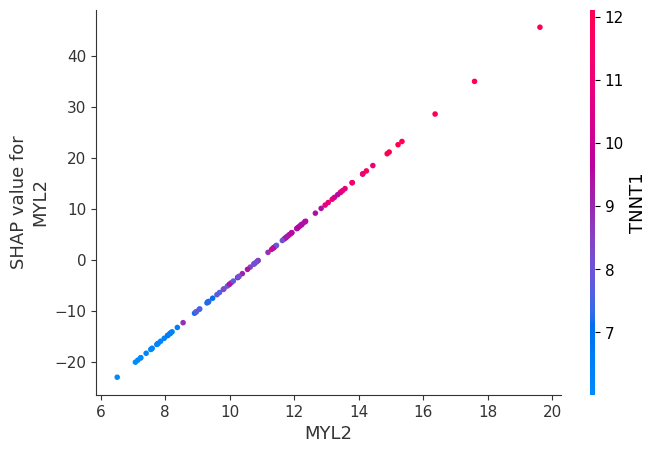

In [46]:
shap.dependence_plot("MYL2", shap_values.values, X_test_data)


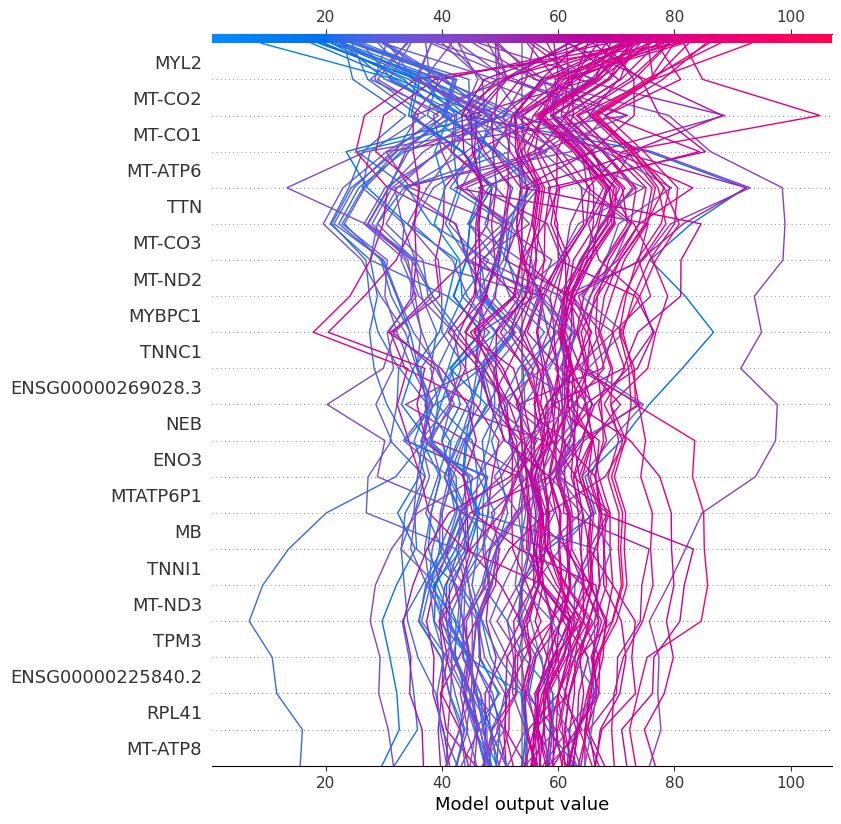

In [47]:
shap.decision_plot(explainer.expected_value, shap_values.values, X_test_data)


In [48]:
# get the list of the columns of X_test_data with their corresponding average value of their shap_values.values
import sys
sys.path.append('/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning')
import getting_threshold_genes as gtg

shap_avg_values = pd.DataFrame({
    'Feature': X_test_data.columns,
    'Average SHAP Value': np.mean(shap_values.values, axis=0)
})
shap_avg_values["abs_coef"] = shap_avg_values["Average SHAP Value"].abs()


elbow_point = gtg.get_elbow_point_from_gene_rank(shap_avg_values)
threshold_genes = shap_avg_values[shap_avg_values["abs_coef"] > elbow_point]
threshold_genes.sort_values(by="abs_coef", ascending=False, inplace=True)
threshold_genes.to_csv("threshold_genes_Ridge_10_extended.csv", index=False)
len(threshold_genes)

129

In [49]:
shap_avg_values

,Feature,Average SHAP Value,abs_coef
0,TSPAN6,8.075701e-07,8.075701e-07
1,TNMD,-5.997209e-06,5.997209e-06
2,DPM1,4.095346e-06,4.095346e-06
3,SCYL3,-3.996510e-06,3.996510e-06
4,FIRRM,-3.216240e-07,3.216240e-07
...,...,...,...
34500,H2BK1,-4.743475e-06,4.743475e-06
34501,OR1Q1BP,-5.707349e-06,5.707349e-06
34502,ENSG00000285505.1,-5.415679e-06,5.415679e-06
34503,ENSG00000285508.1,-1.421668e-07,1.421668e-07


In [ ]:

shap_avg_values = pd.DataFrame({
    'Feature': X_test_data.columns,
    'Average SHAP Value': np.mean(shap_values.values, axis=0)
})
shap_avg_values["abs_coef"] = shap_avg_values["Average SHAP Value"].abs()


elbow_point = gtg.get_elbow_point_from_gene_rank(shap_avg_values)
threshold_genes = shap_avg_values[shap_avg_values["abs_coef"] > elbow_point]
threshold_genes.sort_values(by="abs_coef", ascending=False, inplace=True)
threshold_genes.to_csv("threshold_genes_Ridge_10_extended.csv", index=False)
len(threshold_genes)